Libraries Loaded Successfully

File found at: PS_2026.02.07_05.49.09.csv
Dataset Shape: (39315, 289)
Selected Shape: (39315, 9)

Target Distribution:
habitability
0    38991
1      324
Name: count, dtype: int64

Train Shape: (31452, 9)
Test Shape: (7863, 9)

===== Logistic Regression =====
Accuracy: 0.9931323922167111
Recall: 0.27692307692307694
F1: 0.4

===== Random Forest =====
Best Params: {'classifier__max_depth': 10, 'classifier__n_estimators': 200}
Accuracy: 0.9998728220780873
Recall: 0.9846153846153847
F1: 0.9922480620155039

===== XGBoost =====
Best Params: {'classifier__learning_rate': 0.05, 'classifier__max_depth': 5, 'classifier__n_estimators': 200}
Accuracy: 0.9993641103904363
Recall: 0.9692307692307692
F1: 0.9618320610687023


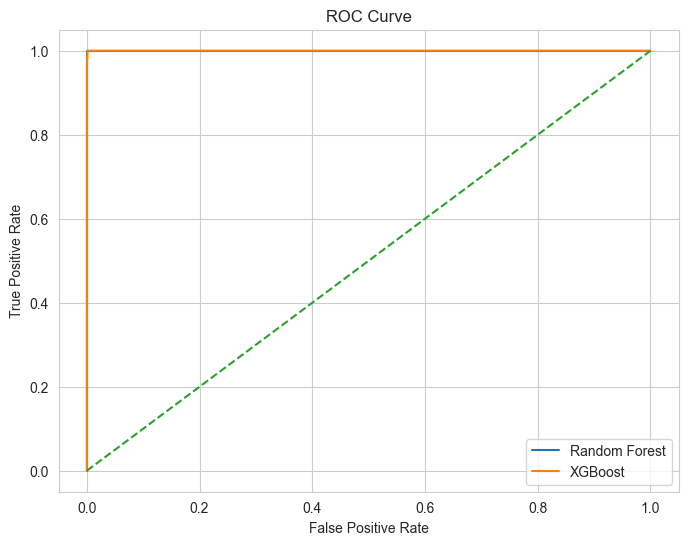


Selected Model: Random Forest
Model Saved Successfully
Ranking File Saved


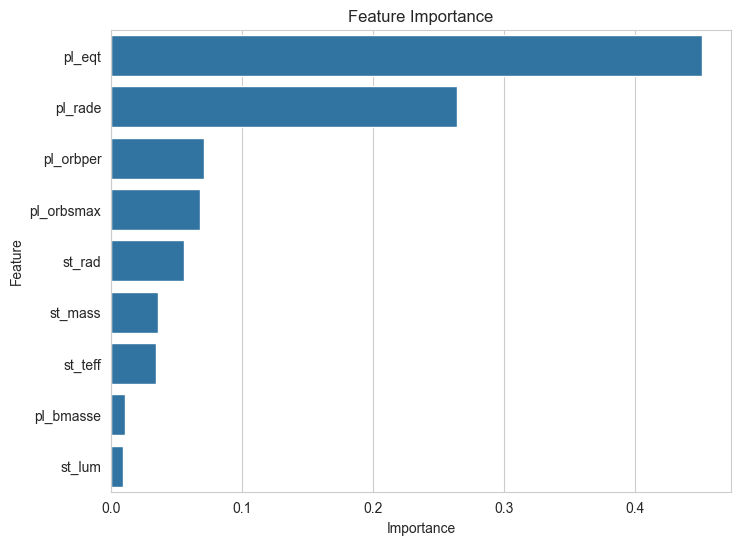


ML Pipeline Completed Successfully – ExoHabitAI


In [ ]:
# =====================================================
# EXOHABITAI – ADVANCED ML TRAINING PIPELINE
# =====================================================

# ==============================
# 1. IMPORT LIBRARIES
# ==============================

import os
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.impute import SimpleImputer

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier

from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, roc_auc_score,
    confusion_matrix, classification_report, roc_curve
)

import joblib

print("Libraries Loaded Successfully\n")

# 2. LOAD DATA (AUTO DETECT PATH)

file_name = "PS_2026.02.07_05.49.09.csv"

possible_paths = [
    file_name,
    f"./{file_name}",
    f"../{file_name}",
    f"data/{file_name}",
    f"../data/{file_name}",
    f"data/raw/{file_name}",
    f"../data/raw/{file_name}"
]

for path in possible_paths:
    if os.path.exists(path):
        print("File found at:", path)
        df = pd.read_csv(path, comment="#", low_memory=False)
        break
else:
    raise FileNotFoundError("CSV file not found.")

print("Dataset Shape:", df.shape)


# ==============================
# 3. SELECT SCIENTIFIC FEATURES
# ==============================

selected_features = [
    'pl_orbper',      # orbital period
    'pl_rade',        # planet radius
    'pl_bmasse',      # planet mass
    'pl_orbsmax',     # semi-major axis
    'pl_eqt',         # equilibrium temp
    'st_teff',        # stellar temperature
    'st_rad',         # stellar radius
    'st_mass',        # stellar mass
    'st_lum'          # stellar luminosity
]

df = df[selected_features].copy()

print("Selected Shape:", df.shape)


# ==============================
# 4. CREATE HABITABILITY LABEL
# ==============================

df['habitability'] = np.where(
    (df['pl_eqt'].between(180, 320)) &
    (df['pl_rade'].between(0.5, 2.5)),
    1, 0
)

print("\nTarget Distribution:")
print(df['habitability'].value_counts())


# ==============================
# 5. DEFINE FEATURES & TARGET
# ==============================

X = df.drop('habitability', axis=1)
y = df['habitability']


# ==============================
# 6. TRAIN-TEST SPLIT
# ==============================

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("\nTrain Shape:", X_train.shape)
print("Test Shape:", X_test.shape)


# ==============================
# 7. PREPROCESSING PIPELINE
# ==============================

numeric_features = X.columns.tolist()

numeric_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

preprocessor = ColumnTransformer([
    ('num', numeric_pipeline, numeric_features)
])


# ==============================
# 8. BASELINE MODEL – LOGISTIC
# ==============================

log_model = Pipeline([
    ('preprocessing', preprocessor),
    ('classifier', LogisticRegression(max_iter=1000))
])

log_model.fit(X_train, y_train)

y_pred_log = log_model.predict(X_test)
y_prob_log = log_model.predict_proba(X_test)[:,1]

print("\n===== Logistic Regression =====")
print("Accuracy:", accuracy_score(y_test, y_pred_log))
print("Recall:", recall_score(y_test, y_pred_log))
print("F1:", f1_score(y_test, y_pred_log))


# ==============================
# 9. RANDOM FOREST + TUNING
# ==============================

rf_pipeline = Pipeline([
    ('preprocessing', preprocessor),
    ('classifier', RandomForestClassifier(random_state=42))
])

rf_params = {
    'classifier__n_estimators': [100, 200],
    'classifier__max_depth': [None, 10, 20]
}

rf_grid = GridSearchCV(
    rf_pipeline,
    rf_params,
    cv=5,
    scoring='f1',
    n_jobs=-1
)

rf_grid.fit(X_train, y_train)

best_rf = rf_grid.best_estimator_

y_pred_rf = best_rf.predict(X_test)
y_prob_rf = best_rf.predict_proba(X_test)[:,1]

print("\n===== Random Forest =====")
print("Best Params:", rf_grid.best_params_)
print("Accuracy:", accuracy_score(y_test, y_pred_rf))
print("Recall:", recall_score(y_test, y_pred_rf))
print("F1:", f1_score(y_test, y_pred_rf))


# ==============================
# 10. XGBOOST + TUNING
# ==============================

xgb_pipeline = Pipeline([
    ('preprocessing', preprocessor),
    ('classifier', XGBClassifier(
        use_label_encoder=False,
        eval_metric='logloss',
        random_state=42
    ))
])

xgb_params = {
    'classifier__n_estimators': [100, 200],
    'classifier__max_depth': [3, 5],
    'classifier__learning_rate': [0.05, 0.1]
}

xgb_grid = GridSearchCV(
    xgb_pipeline,
    xgb_params,
    cv=5,
    scoring='f1',
    n_jobs=-1
)

xgb_grid.fit(X_train, y_train)

best_xgb = xgb_grid.best_estimator_

y_pred_xgb = best_xgb.predict(X_test)
y_prob_xgb = best_xgb.predict_proba(X_test)[:,1]

print("\n===== XGBoost =====")
print("Best Params:", xgb_grid.best_params_)
print("Accuracy:", accuracy_score(y_test, y_pred_xgb))
print("Recall:", recall_score(y_test, y_pred_xgb))
print("F1:", f1_score(y_test, y_pred_xgb))


# ==============================
# 11. ROC CURVE
# ==============================

fpr_rf, tpr_rf, _ = roc_curve(y_test, y_prob_rf)
fpr_xgb, tpr_xgb, _ = roc_curve(y_test, y_prob_xgb)

plt.figure(figsize=(8,6))
plt.plot(fpr_rf, tpr_rf, label="Random Forest")
plt.plot(fpr_xgb, tpr_xgb, label="XGBoost")
plt.plot([0,1],[0,1],'--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()
plt.show()


# ==============================
# 12. SELECT BEST MODEL
# ==============================

if f1_score(y_test, y_pred_xgb) > f1_score(y_test, y_pred_rf):
    final_model = best_xgb
    print("\nSelected Model: XGBoost")
else:
    final_model = best_rf
    print("\nSelected Model: Random Forest")


# ==============================
# 13. SAVE MODEL
# ==============================

os.makedirs("models", exist_ok=True)
joblib.dump(final_model, "models/final_model.pkl")
print("Model Saved Successfully")


# ==============================
# 14. HABITABILITY RANKING
# ==============================

df['habitability_score'] = final_model.predict_proba(X)[:,1]

ranked_df = df.sort_values(by='habitability_score', ascending=False)

os.makedirs("data/processed", exist_ok=True)
ranked_df.to_csv("data/processed/habitability_ranked.csv", index=False)

print("Ranking File Saved")


# ==============================
# 15. FEATURE IMPORTANCE
# ==============================

if hasattr(final_model.named_steps['classifier'], 'feature_importances_'):
    importances = final_model.named_steps['classifier'].feature_importances_
    feature_names = numeric_features
    
    importance_df = pd.DataFrame({
        'Feature': feature_names,
        'Importance': importances
    }).sort_values(by='Importance', ascending=False)
    
    plt.figure(figsize=(8,6))
    sns.barplot(data=importance_df, x='Importance', y='Feature')
    plt.title("Feature Importance")
    plt.show()

print("\nML Pipeline Completed Successfully – ExoHabitAI")

# Machine Learning Model Selection & Training

## 1. Model Selection Justification

## 2. Scientific Feature Justification

## 3. Overfitting Handling & Model Validation